In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

warnings.filterwarnings("ignore")

In [55]:
df = pd.read_csv("../data/data_features.csv", parse_dates=["Date"])
df = df.sort_values(["Date", "ticker"]).reset_index(drop=True)
print(df.shape)

(37603, 42)


In [56]:
FEATURES = [col for col in df.columns if col not in 
            ["Date", "ticker", "target_3d", "target_5d", 
             "target_10d", "target_30d", "target_90d", "target_365d"]]

HORIZONS = [3, 5, 10, 30, 90, 365]

print(f"Признаков: {len(FEATURES)}")
print(FEATURES)

Признаков: 34
['MACD_diff', 'RSI', 'BB_width', 'return_1d', 'return_3d', 'return_5d', 'return_10d', 'return_20d', 'close_to_ema20', 'close_to_ema50', 'ema20_to_ema50', 'bb_position', 'volume_ratio', 'macd_ratio', 'RSI_lag1', 'RSI_lag2', 'RSI_lag3', 'RSI_lag5', 'MACD_diff_lag1', 'MACD_diff_lag2', 'MACD_diff_lag3', 'MACD_diff_lag5', 'bb_position_lag1', 'bb_position_lag2', 'bb_position_lag3', 'bb_position_lag5', 'volume_ratio_lag1', 'volume_ratio_lag2', 'volume_ratio_lag3', 'volume_ratio_lag5', 'return_1d_lag1', 'return_1d_lag2', 'return_1d_lag3', 'return_1d_lag5']


In [57]:
train = df[df["Date"] < "2023-01-01"]
test  = df[df["Date"] >= "2023-01-01"]

print(f"Train: {len(train)} строк ({train['Date'].min().date()} — {train['Date'].max().date()})")
print(f"Test:  {len(test)} строк ({test['Date'].min().date()} — {test['Date'].max().date()})")

Train: 25200 строк (2016-04-13 — 2022-12-30)
Test:  12403 строк (2023-01-03 — 2025-12-30)


In [58]:
def train_model(horizon):
    target = f"target_{horizon}d"

    X_train = train[FEATURES]
    y_train = train[target]
    X_test  = test[FEATURES]
    y_test  = test[target]

    classes = np.array([0, 1, 2])
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    weight_dict = dict(zip(classes, weights))
    sample_weights = y_train.map(weight_dict)

    model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1
    )

    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_pred = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"Горизонт {horizon} дней:")
    print(classification_report(y_test, y_pred, target_names=["Продавать", "Держать", "Покупать"]))

    return model, y_test, y_pred


In [59]:
models = {}
results = {}

for h in HORIZONS:
    model, y_test, y_pred = train_model(h)
    models[h] = model
    results[h] = {"y_test": y_test, "y_pred": y_pred}


Горизонт 3 дней:
              precision    recall  f1-score   support

   Продавать       0.17      0.16      0.17      1584
     Держать       0.78      0.70      0.73      9137
    Покупать       0.18      0.28      0.22      1682

    accuracy                           0.57     12403
   macro avg       0.37      0.38      0.37     12403
weighted avg       0.62      0.57      0.59     12403


Горизонт 5 дней:
              precision    recall  f1-score   support

   Продавать       0.21      0.17      0.19      2338
     Держать       0.67      0.60      0.63      7641
    Покупать       0.23      0.35      0.28      2424

    accuracy                           0.47     12403
   macro avg       0.37      0.37      0.37     12403
weighted avg       0.50      0.47      0.48     12403


Горизонт 10 дней:
              precision    recall  f1-score   support

   Продавать       0.28      0.20      0.23      3278
     Держать       0.52      0.47      0.49      5728
    Покупать       0

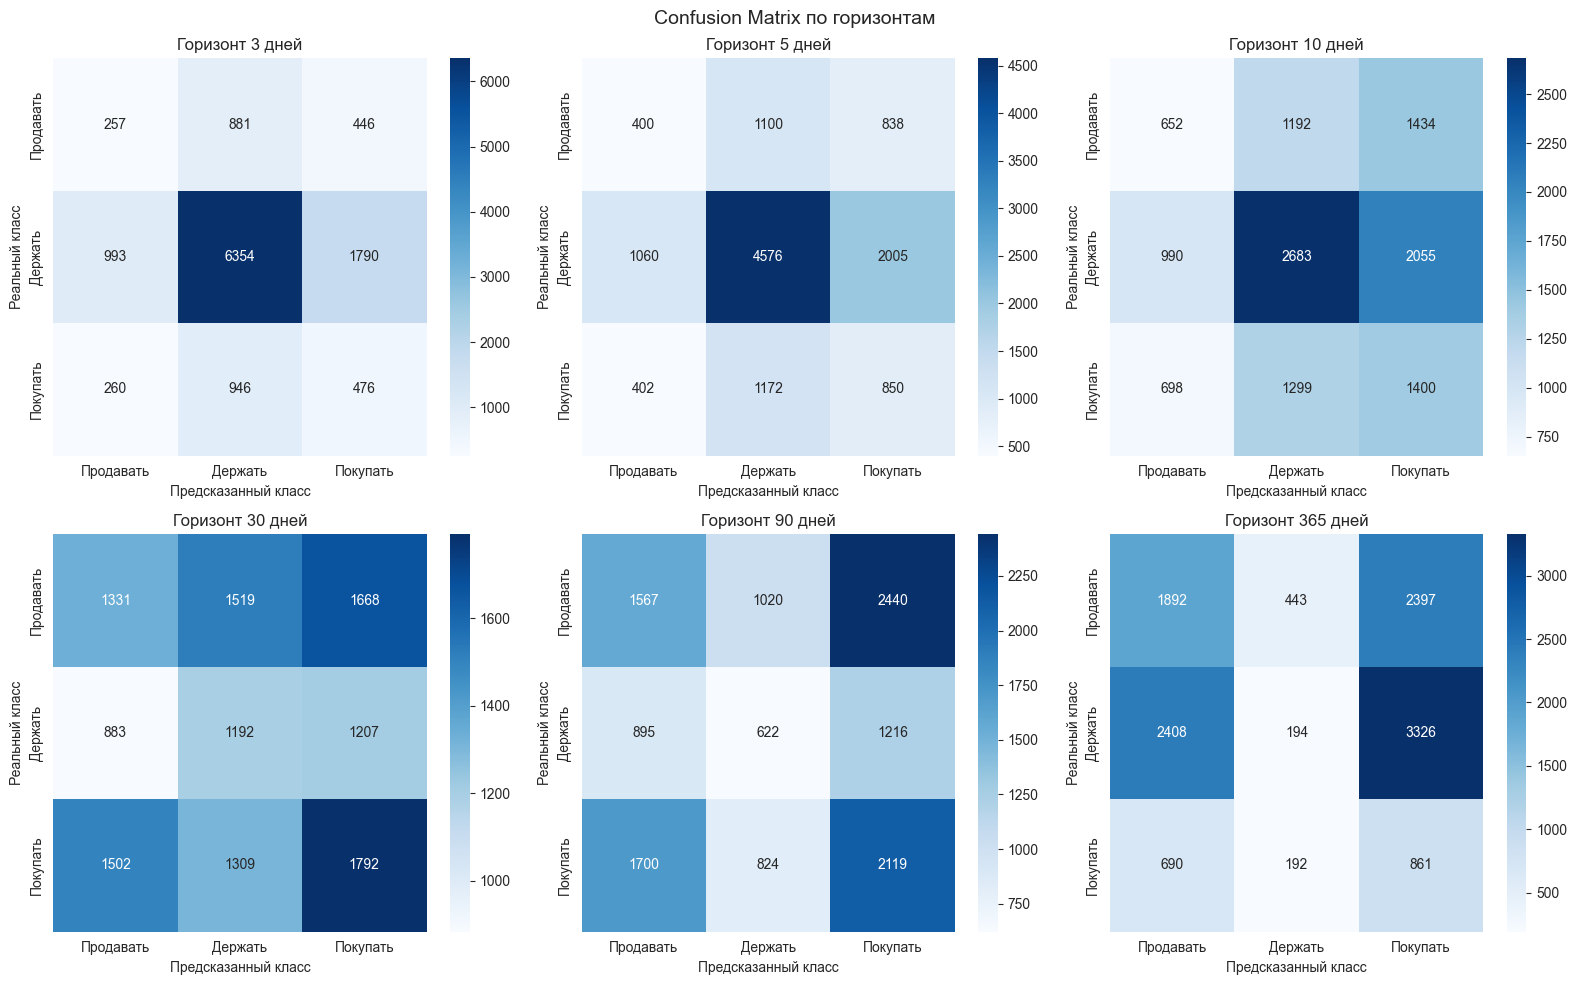

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, h in enumerate(HORIZONS):
    cm = confusion_matrix(results[h]["y_test"], results[h]["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", ax=axes[i],
        xticklabels=["Продавать", "Держать", "Покупать"],
        yticklabels=["Продавать", "Держать", "Покупать"],
        cmap="Blues"
    )
    axes[i].set_title(f"Горизонт {h} дней")
    axes[i].set_ylabel("Реальный класс")
    axes[i].set_xlabel("Предсказанный класс")

plt.suptitle("Confusion Matrix по горизонтам", fontsize=14)
plt.tight_layout()
plt.show()

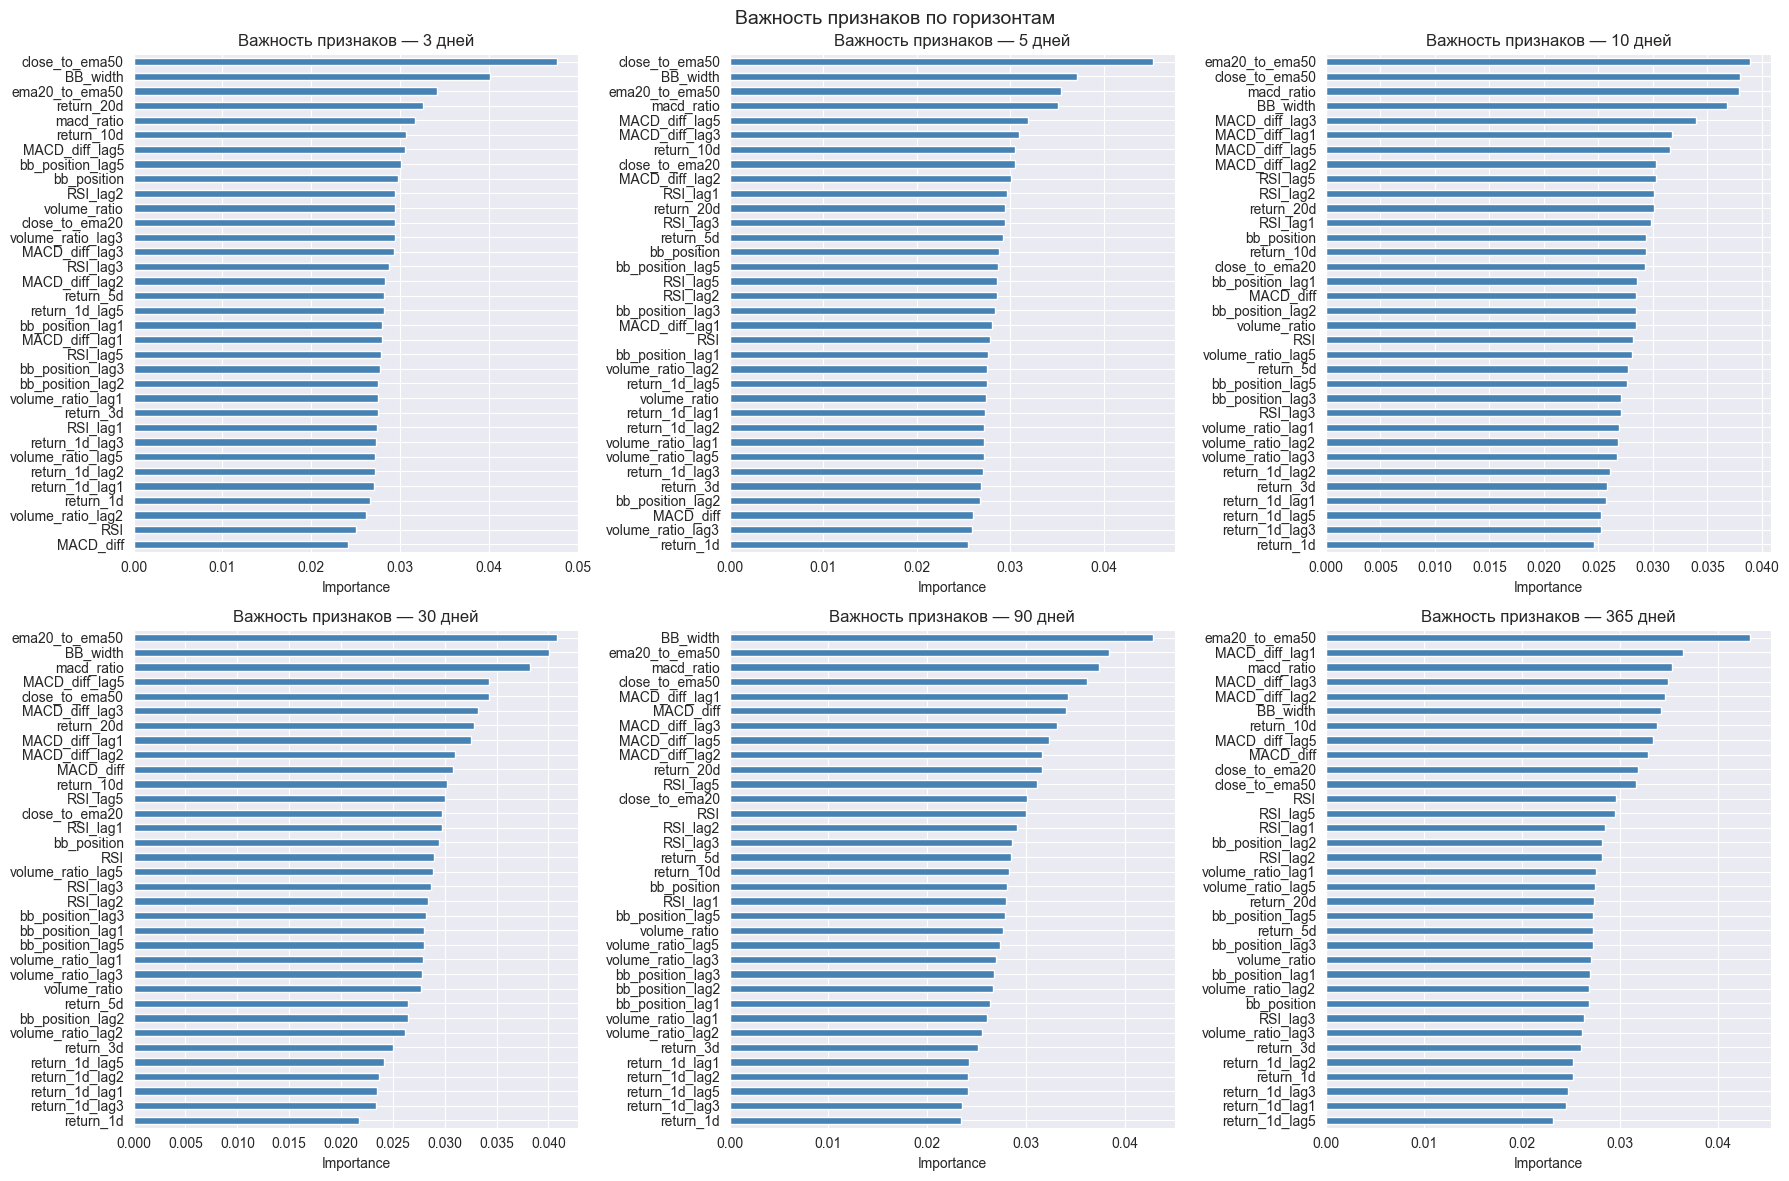

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, h in enumerate(HORIZONS):
    feat_imp = pd.Series(
        models[h].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)

    feat_imp.plot(kind="barh", ax=axes[i], color="steelblue")
    axes[i].set_title(f"Важность признаков — {h} дней")
    axes[i].set_xlabel("Importance")

plt.suptitle("Важность признаков по горизонтам", fontsize=14)
plt.tight_layout()
plt.show()

In [62]:
import os
os.makedirs("../model", exist_ok=True)

for h in HORIZONS:
    path = f"../model/model_{h}d.pkl"
    joblib.dump(models[h], path)
    print(f"Сохранено: {path}")

joblib.dump(FEATURES, "../model/features.pkl")
print("Сохранено: features.pkl")

Сохранено: ../model/model_3d.pkl
Сохранено: ../model/model_5d.pkl
Сохранено: ../model/model_10d.pkl
Сохранено: ../model/model_30d.pkl
Сохранено: ../model/model_90d.pkl
Сохранено: ../model/model_365d.pkl
Сохранено: features.pkl
